## Linear Classifier in TensorFlow 
Using Low Level API in Eager Execution mode

### Load tensorflow

In [73]:
import tensorflow as tf

### Collect Data

In [74]:
import pandas as pd
import numpy as np

In [75]:
data = pd.read_csv('prices.csv')

### Check all columns in the dataset

In [76]:
data.shape

(851264, 7)

In [77]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
date      851264 non-null object
symbol    851264 non-null object
open      851264 non-null float64
close     851264 non-null float64
low       851264 non-null float64
high      851264 non-null float64
volume    851264 non-null float64
dtypes: float64(5), object(2)
memory usage: 45.5+ MB


In [78]:
#There are 851264 and 7 columns

### Drop columns `date` and  `symbol`

In [79]:
data = data.drop(["date","symbol"],axis=1)

In [80]:
data.head()

,open,close,low,high,volume
0,123.430000,125.839996,122.309998,126.250000,2163600.0
1,125.239998,119.980003,119.940002,125.540001,2386400.0
2,116.379997,114.949997,114.930000,119.739998,2489500.0
3,115.480003,116.620003,113.500000,117.440002,2006300.0
4,117.010002,114.970001,114.089996,117.330002,1408600.0


### Consider only first 1000 rows in the dataset for building feature set and target set
Target 'Volume' has very high values. Divide 'Volume' by 1000,000

In [81]:
data = data.head(1000)

In [82]:
data.shape

(1000, 5)

In [83]:
data["volume"]= data["volume"]/1000000

In [84]:
data["volume"].head()

0    2.1636
1    2.3864
2    2.4895
3    2.0063
4    1.4086
Name: volume, dtype: float64

### Divide the data into train and test sets

In [135]:
from sklearn.model_selection import train_test_split

In [136]:
# split into 70% for train and 30% for test
X = data.drop( ["volume"] ,axis=1).values
y = data["volume"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=7)

#### Convert Training and Test Data to numpy float32 arrays


In [137]:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

### Normalize the data
You can use Normalizer from sklearn.preprocessing

In [138]:
from sklearn.preprocessing import normalize
X_train = normalize(X_train)
X_test = normalize(X_test)

## Building the Model in tensorflow

1.Define Weights and Bias, use tf.zeros to initialize weights and Bias

In [139]:
#Input features
x = tf.placeholder(shape=[None,4],dtype=tf.float32, name='x-input')
#Normalize the data
x_n = tf.nn.l2_normalize(x,1)
#Actual Prices
y_ = tf.placeholder(shape=[None],dtype=tf.float32, name='y-input')
W = tf.Variable(tf.zeros(shape=[4,1]), name="Weights")
b = tf.Variable(tf.zeros(shape=[1]),name="Bias")
y = tf.add(tf.matmul(x_n,W),b,name='output')

2.Define a function to calculate prediction

In [148]:
def predict(x,w,b):
    return tf.add(tf.matmul(x,w),b)

3.Loss (Cost) Function [Mean square error]

In [141]:
mse = tf.reduce_mean(tf.square(y-y_),name='mse')

4.Function to train the Model

1.   Record all the mathematical steps to calculate Loss
2.   Calculate Gradients of Loss w.r.t weights and bias
3.   Update Weights and Bias based on gradients and learning rate to minimize loss

In [142]:
train_op = tf.train.GradientDescentOptimizer(0.03).minimize(mse)

## Train the model for 100 epochs 
1. Observe the training loss at every iteration
2. Observe Train loss at every 5th iteration

In [143]:
#Lets start graph Execution
sess = tf.Session()

# variables need to be initialized before we can use them
sess.run(tf.global_variables_initializer())

#how many times data need to be shown to model
training_epochs = 100

In [144]:
for epoch in range(training_epochs):

    _, train_loss = sess.run([train_op,mse],feed_dict={x:X_train, y_:y_train})
    
    if epoch % 5 == 0:
        print ('Training loss at step: ', epoch, ' is ', train_loss)

Training loss at step:  0  is  305.42902
Training loss at step:  5  is  282.72012
Training loss at step:  10  is  276.39557
Training loss at step:  15  is  274.634
Training loss at step:  20  is  274.14355
Training loss at step:  25  is  274.0067
Training loss at step:  30  is  273.96872
Training loss at step:  35  is  273.95813
Training loss at step:  40  is  273.95538
Training loss at step:  45  is  273.95447
Training loss at step:  50  is  273.95425
Training loss at step:  55  is  273.95407
Training loss at step:  60  is  273.9541
Training loss at step:  65  is  273.95413
Training loss at step:  70  is  273.95416
Training loss at step:  75  is  273.9542
Training loss at step:  80  is  273.95425
Training loss at step:  85  is  273.95428
Training loss at step:  90  is  273.95425
Training loss at step:  95  is  273.95422


### Get the shapes and values of W and b

In [145]:
print(sess.run(W)) 

[[1.4007461]
 [1.4055865]
 [1.3863369]
 [1.4173869]]


In [146]:
print(sess.run(b)) 

[2.8051822]


### Model Prediction on 1st Examples in Test Dataset

In [150]:
y_pred1 =predict(X_test[0:1],W,b)
sess.run(y_pred1)
#print("Model Prediction on 1st Examples in Test Dataset",sess.run(y_pred))

array([[5.61012]], dtype=float32)

In [152]:
mse1 = sess.run([mse],feed_dict={x:X_test, y_:y_test})

In [154]:
print(mse1)

[57.884933]


## Classification using tf.Keras

In this exercise, we will build a Deep Neural Network using tf.Keras. We will use Iris Dataset for this exercise.

### Load the given Iris data using pandas (Iris.csv)

In [196]:
 df_ir= pd.read_csv('11_Iris.csv')

In [197]:
df_ir.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
Id               150 non-null int64
SepalLengthCm    150 non-null float64
SepalWidthCm     150 non-null float64
PetalLengthCm    150 non-null float64
PetalWidthCm     150 non-null float64
Species          150 non-null object
dtypes: float64(4), int64(1), object(1)
memory usage: 7.1+ KB


### Target set has different categories. So, Label encode them. And convert into one-hot vectors using get_dummies in pandas.

In [198]:
df_ir.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [199]:
df_ir =df_ir.drop(["Id"],axis=1)

In [200]:
X= df_ir.drop(["Species"],axis=1)
y= df_ir["Species"]

In [201]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

In [202]:
# One hot encoding
enc = OneHotEncoder()
Y = enc.fit_transform(y[:, np.newaxis]).toarray()

In [203]:
cols = ["Iris-Setosa","Iris-Versicolor","Iris-Virginica"]
y= pd.DataFrame(Y,columns=cols)

In [204]:
y.head()

,Iris-Setosa,Iris-Versicolor,Iris-Virginica
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


In [205]:
# Scale data to have mean 0 and variance 1 
# which is importance for convergence of the neural network
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data set into training and testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=7)

### Splitting the data into feature set and target set

###  Building Model in tf.keras

Build a Linear Classifier model  <br>
1.  Use Dense Layer  with input shape of 4 (according to the feature set) and number of outputs set to 3<br> 
2. Apply Softmax on Dense Layer outputs <br>
3. Use SGD as Optimizer
4. Use categorical_crossentropy as loss function 

In [206]:
from keras.models import Sequential
from keras.layers import Dense

In [207]:
model = Sequential()
model.add(Dense(3, input_dim=4, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='sgd')

### Model Training 

In [208]:
# Fit the model
hist=model.fit(X_train, y_train, epochs=300, batch_size=5)

Epoch 1/300
105/105 [==============================] - 0s 2ms/step - loss: 1.0925
Epoch 2/300
105/105 [==============================] - 0s 161us/step - loss: 0.9852
Epoch 3/300
105/105 [==============================] - 0s 266us/step - loss: 0.8980
Epoch 4/300
105/105 [==============================] - 0s 295us/step - loss: 0.8248
Epoch 5/300
105/105 [==============================] - 0s 237us/step - loss: 0.7634
Epoch 6/300
105/105 [==============================] - 0s 332us/step - loss: 0.7112
Epoch 7/300
105/105 [==============================] - 0s 294us/step - loss: 0.6669
Epoch 8/300
105/105 [==============================] - 0s 313us/step - loss: 0.6291
Epoch 9/300
105/105 [==============================] - 0s 295us/step - loss: 0.5964
Epoch 10/300
105/105 [==============================] - 0s 237us/step - loss: 0.5681
Epoch 11/300
105/105 [==============================] - 0s 284us/step - loss: 0.5430
Epoch 12/300
105/105 [==============================] - 0s 294us/step - loss

105/105 [==============================] - 0s 294us/step - loss: 0.2222
Epoch 98/300
105/105 [==============================] - 0s 294us/step - loss: 0.2213
Epoch 99/300
105/105 [==============================] - 0s 304us/step - loss: 0.2203
Epoch 100/300
105/105 [==============================] - 0s 389us/step - loss: 0.2194
Epoch 101/300
105/105 [==============================] - 0s 285us/step - loss: 0.2185
Epoch 102/300
105/105 [==============================] - 0s 389us/step - loss: 0.2176
Epoch 103/300
105/105 [==============================] - 0s 313us/step - loss: 0.2168
Epoch 104/300
105/105 [==============================] - 0s 323us/step - loss: 0.2158
Epoch 105/300
105/105 [==============================] - 0s 380us/step - loss: 0.2150
Epoch 106/300
105/105 [==============================] - 0s 275us/step - loss: 0.2141
Epoch 107/300
105/105 [==============================] - 0s 313us/step - loss: 0.2132
Epoch 108/300
105/105 [==============================] - 0s 285us/step

105/105 [==============================] - 0s 285us/step - loss: 0.1629
Epoch 193/300
105/105 [==============================] - 0s 294us/step - loss: 0.1625
Epoch 194/300
105/105 [==============================] - 0s 247us/step - loss: 0.1620
Epoch 195/300
105/105 [==============================] - 0s 304us/step - loss: 0.1616
Epoch 196/300
105/105 [==============================] - ETA: 0s - loss: 0.023 - 0s 275us/step - loss: 0.1612
Epoch 197/300
105/105 [==============================] - 0s 342us/step - loss: 0.1608
Epoch 198/300
105/105 [==============================] - 0s 238us/step - loss: 0.1604
Epoch 199/300
105/105 [==============================] - 0s 247us/step - loss: 0.1600
Epoch 200/300
105/105 [==============================] - 0s 237us/step - loss: 0.1596
Epoch 201/300
105/105 [==============================] - 0s 275us/step - loss: 0.1593
Epoch 202/300
105/105 [==============================] - 0s 275us/step - loss: 0.1588
Epoch 203/300
105/105 [=====================

105/105 [==============================] - 0s 275us/step - loss: 0.1326
Epoch 288/300
105/105 [==============================] - 0s 294us/step - loss: 0.1324
Epoch 289/300
105/105 [==============================] - 0s 361us/step - loss: 0.1323
Epoch 290/300
105/105 [==============================] - 0s 323us/step - loss: 0.1320
Epoch 291/300
105/105 [==============================] - 0s 304us/step - loss: 0.1317
Epoch 292/300
105/105 [==============================] - 0s 199us/step - loss: 0.1316
Epoch 293/300
105/105 [==============================] - 0s 342us/step - loss: 0.1313
Epoch 294/300
105/105 [==============================] - 0s 237us/step - loss: 0.1310
Epoch 295/300
105/105 [==============================] - 0s 237us/step - loss: 0.1308
Epoch 296/300
105/105 [==============================] - 0s 351us/step - loss: 0.1305
Epoch 297/300
105/105 [==============================] - 0s 410us/step - loss: 0.1303
Epoch 298/300
105/105 [==============================] - 0s 244us/st

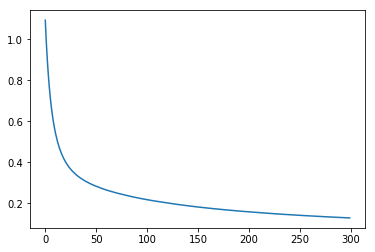

In [209]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(hist.history['loss'])

### Model Prediction

In [210]:
model.predict(X_test)

array([[4.4593201e-03, 2.7333084e-01, 7.2220981e-01],
       [6.3963868e-02, 6.5941203e-01, 2.7662414e-01],
       [9.9470842e-01, 5.2895308e-03, 2.0372031e-06],
       [4.4563547e-02, 6.6261375e-01, 2.9282272e-01],
       [9.4935205e-03, 6.5865487e-01, 3.3185163e-01],
       [4.6663359e-01, 5.3331649e-01, 4.9935206e-05],
       [3.7388424e-03, 5.1791179e-01, 4.7834936e-01],
       [2.0014657e-02, 8.8265443e-01, 9.7330913e-02],
       [9.9260229e-01, 7.3957285e-03, 1.9784218e-06],
       [2.5783675e-02, 5.8192945e-01, 3.9228696e-01],
       [1.5358921e-03, 3.3512786e-01, 6.6333622e-01],
       [9.9442810e-02, 4.1887462e-01, 4.8168257e-01],
       [9.9967408e-01, 3.2577323e-04, 1.2441861e-07],
       [2.3565981e-05, 3.5025703e-03, 9.9647385e-01],
       [9.8730993e-01, 1.2686737e-02, 3.2550679e-06],
       [1.6693039e-02, 2.7091131e-01, 7.1239561e-01],
       [3.4133485e-05, 2.3949616e-01, 7.6046968e-01],
       [1.3799750e-03, 1.8209378e-01, 8.1652629e-01],
       [9.9841392e-01, 1.585

In [212]:
scores = model.evaluate(X_test, y_test)
print("score=", scores)

45/45 [==============================] - 0s 66us/step
score= 0.28703080117702484


### Save the Model

In [213]:
model.save("11_iris.h5")

### Build and Train a Deep Neural network with 2 hidden layer  - Optional - For Practice

Does it perform better than Linear Classifier? What could be the reason for difference in performance?

In [262]:
model = Sequential()
model.add(Dense(5, input_dim=4, activation='relu'))
model.add(Dense(3, activation='softmax'))
#model.add(Dense(3, activation='relu'))
# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [263]:
from keras.callbacks import TensorBoard

history_dict = {}
# TensorBoard Callback
cb = TensorBoard()
history_callback = model.fit(X_train, y_train,
                                 batch_size=5,
                                 epochs=500,
                                 verbose=0,
                                 validation_data=(X_test, y_test),
                                 callbacks=[cb])
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])    
history_dict[model.name] = [history_callback, model]

Test loss: 0.19904635937160087
Test accuracy: 0.9111111111111111


No handles with labels found to put in legend.
No handles with labels found to put in legend.


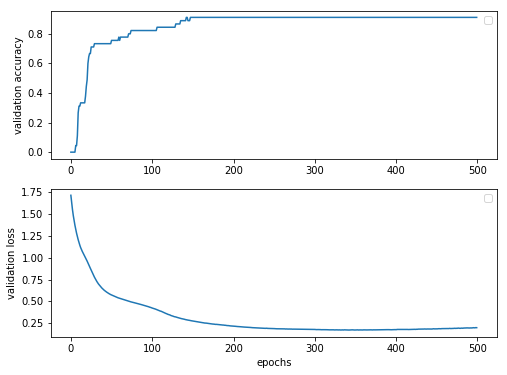

In [264]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(8, 6))

for model_name in history_dict:
    val_acc = history_dict[model_name][0].history['val_acc']
    val_loss = history_dict[model_name][0].history['val_loss']
    ax1.plot(val_acc)
    ax2.plot(val_loss)
    
ax1.set_ylabel('validation accuracy')
ax2.set_ylabel('validation loss')
ax2.set_xlabel('epochs')
ax1.legend()
ax2.legend()
plt.show()